In [13]:
import sys

!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn wordcloud nltk

In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import nltk
from nltk.corpus import stopwords

print("All libraries imported successfully!")

All libraries imported successfully!


In [15]:
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

print("Stopwords loaded:", len(stop_words))

Stopwords loaded: 198


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/nishantpawar/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [17]:
df = pd.read_csv("IMDB Dataset.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [18]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset Shape: (50000, 2)

Columns:
['review', 'sentiment']

First 5 rows:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [20]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
review       0
sentiment    0
dtype: int64


In [21]:
missing_percentage = (
    df.isnull().mean() * 100
).round(2)

print("\nMissing Value Percentage:")
print(missing_percentage)


Missing Value Percentage:
review       0.0
sentiment    0.0
dtype: float64


In [22]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 418


In [23]:
print(df["sentiment"].value_counts())

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


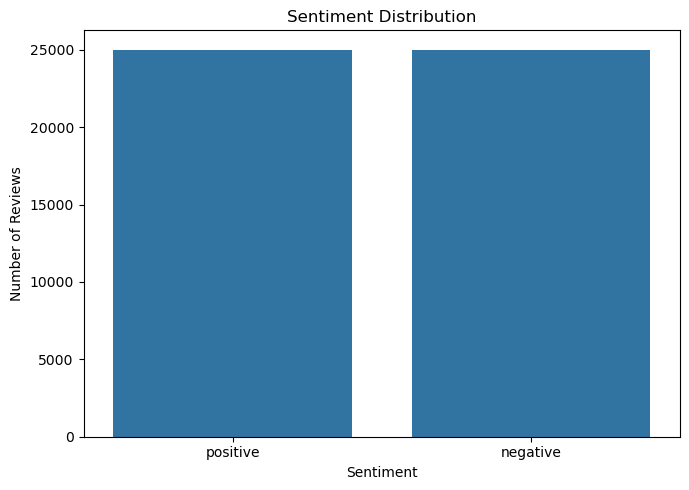

In [24]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="sentiment"
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

In [25]:
clean_df = df.copy()

print("Copy created successfully.")

Copy created successfully.


In [26]:
print(
    "Missing values before cleaning:",
    clean_df.isnull().sum().sum()
)

clean_df = clean_df.dropna(
    subset=["review", "sentiment"]
)

print(
    "Missing values after cleaning:",
    clean_df.isnull().sum().sum()
)

Missing values before cleaning: 0
Missing values after cleaning: 0


In [27]:
duplicates_before = clean_df.duplicated(
    subset=["review"]
).sum()

clean_df = clean_df.drop_duplicates(
    subset=["review"]
)

duplicates_after = clean_df.duplicated(
    subset=["review"]
).sum()

print("Duplicates before cleaning:", duplicates_before)
print("Duplicates after cleaning:", duplicates_after)
print(
    "Duplicates removed:",
    duplicates_before - duplicates_after
)

Duplicates before cleaning: 418
Duplicates after cleaning: 0
Duplicates removed: 418


In [28]:
print("Cleaned Dataset Shape:", clean_df.shape)

display(clean_df.head())

Cleaned Dataset Shape: (49582, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [29]:
def clean_text(text):
    
    # Convert to string
    text = str(text)
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove HTML tags
    text = re.sub(
        r"<.*?>",
        " ",
        text
    )
    
    # Remove URLs
    text = re.sub(
        r"http\S+|www\S+",
        " ",
        text
    )
    
    # Remove punctuation
    text = text.translate(
        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )
    
    # Remove numbers
    text = re.sub(
        r"\d+",
        " ",
        text
    )
    
    # Remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()
    
    # Remove stopwords
    words = text.split()
    
    words = [
        word
        for word in words
        if word not in stop_words
    ]
    
    return " ".join(words)

In [30]:
clean_df["cleaned_review"] = (
    clean_df["review"].apply(clean_text)
)

display(
    clean_df[
        ["review", "cleaned_review"]
    ].head(10)
)

,review,cleaned_review
0,One of the other reviewers has mentioned that ...,one reviewers mentioned watching oz episode yo...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically theres family little boy jake thinks...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...
5,"Probably my all-time favorite movie, a story o...",probably alltime favorite movie story selfless...
6,I sure would like to see a resurrection of a u...,sure would like see resurrection dated seahunt...
7,"This show was an amazing, fresh & innovative i...",show amazing fresh innovative idea first aired...
8,Encouraged by the positive comments about this...,encouraged positive comments film looking forw...
9,If you like original gut wrenching laughter yo...,like original gut wrenching laughter like movi...


In [31]:
clean_df = clean_df[
    clean_df["cleaned_review"].str.strip() != ""
]

clean_df = clean_df.reset_index(
    drop=True
)

print(
    "Dataset after removing empty reviews:",
    clean_df.shape
)

Dataset after removing empty reviews: (49582, 3)


In [32]:
clean_df["sentiment_label"] = (
    clean_df["sentiment"].map({
        "negative": 0,
        "positive": 1
    })
)

In [33]:
display(
    clean_df[
        ["sentiment", "sentiment_label"]
    ].head(10)
)

,sentiment,sentiment_label
0,positive,1
1,positive,1
2,positive,1
3,negative,0
4,positive,1
5,positive,1
6,positive,1
7,negative,0
8,negative,0
9,positive,1


In [34]:
print(
    clean_df["sentiment_label"].value_counts()
)

print(
    "\nMissing encoded labels:",
    clean_df["sentiment_label"].isnull().sum()
)

sentiment_label
1    24884
0    24698
Name: count, dtype: int64

Missing encoded labels: 0


In [35]:
X = clean_df["cleaned_review"]

y = clean_df["sentiment_label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (49582,)
y shape: (49582,)


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training reviews:", len(X_train))
print("Testing reviews:", len(X_test))

Training reviews: 39665
Testing reviews: 9917


In [37]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2
)

print("TF-IDF vectorizer created.")

TF-IDF vectorizer created.


In [38]:
X_train_tfidf = tfidf.fit_transform(
    X_train
)

print(
    "Training TF-IDF shape:",
    X_train_tfidf.shape
)

Training TF-IDF shape: (39665, 10000)


In [39]:
X_test_tfidf = tfidf.transform(
    X_test
)

print(
    "Testing TF-IDF shape:",
    X_test_tfidf.shape
)

Testing TF-IDF shape: (9917, 10000)


In [40]:
nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [41]:
nb_predictions = nb_model.predict(
    X_test_tfidf
)

print("Naive Bayes predictions completed.")

Naive Bayes predictions completed.


In [42]:
nb_accuracy = accuracy_score(
    y_test,
    nb_predictions
)

nb_precision = precision_score(
    y_test,
    nb_predictions
)

nb_recall = recall_score(
    y_test,
    nb_predictions
)

nb_f1 = f1_score(
    y_test,
    nb_predictions
)

print("Naive Bayes Results")
print("----------------------------")
print("Accuracy :", round(nb_accuracy, 4))
print("Precision:", round(nb_precision, 4))
print("Recall   :", round(nb_recall, 4))
print("F1 Score :", round(nb_f1, 4))

Naive Bayes Results
----------------------------
Accuracy : 0.8649
Precision: 0.8561
Recall   : 0.8784
F1 Score : 0.8671


In [43]:
print(
    classification_report(
        y_test,
        nb_predictions,
        target_names=[
            "Negative",
            "Positive"
        ]
    )
)

              precision    recall  f1-score   support

    Negative       0.87      0.85      0.86      4940
    Positive       0.86      0.88      0.87      4977

    accuracy                           0.86      9917
   macro avg       0.87      0.86      0.86      9917
weighted avg       0.87      0.86      0.86      9917



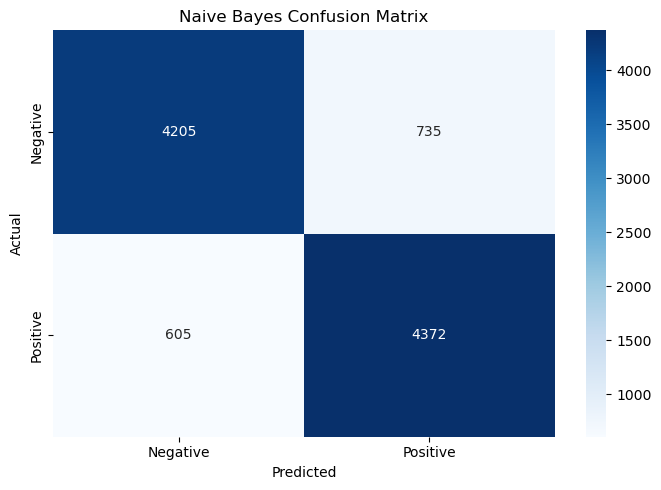

In [44]:
nb_cm = confusion_matrix(
    y_test,
    nb_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    nb_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Negative",
        "Positive"
    ],
    yticklabels=[
        "Negative",
        "Positive"
    ]
)

plt.title(
    "Naive Bayes Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [45]:
lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(
    X_train_tfidf,
    y_train
)

print(
    "Logistic Regression model trained successfully!"
)

Logistic Regression model trained successfully!


In [46]:
lr_predictions = lr_model.predict(
    X_test_tfidf
)

print(
    "Logistic Regression predictions completed."
)

Logistic Regression predictions completed.


In [47]:
lr_accuracy = accuracy_score(
    y_test,
    lr_predictions
)

lr_precision = precision_score(
    y_test,
    lr_predictions
)

lr_recall = recall_score(
    y_test,
    lr_predictions
)

lr_f1 = f1_score(
    y_test,
    lr_predictions
)

print("Logistic Regression Results")
print("----------------------------")
print("Accuracy :", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1 Score :", round(lr_f1, 4))

Logistic Regression Results
----------------------------
Accuracy : 0.893
Precision: 0.8842
Recall   : 0.9054
F1 Score : 0.8947


In [48]:
print(
    classification_report(
        y_test,
        lr_predictions,
        target_names=[
            "Negative",
            "Positive"
        ]
    )
)

              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89      4940
    Positive       0.88      0.91      0.89      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



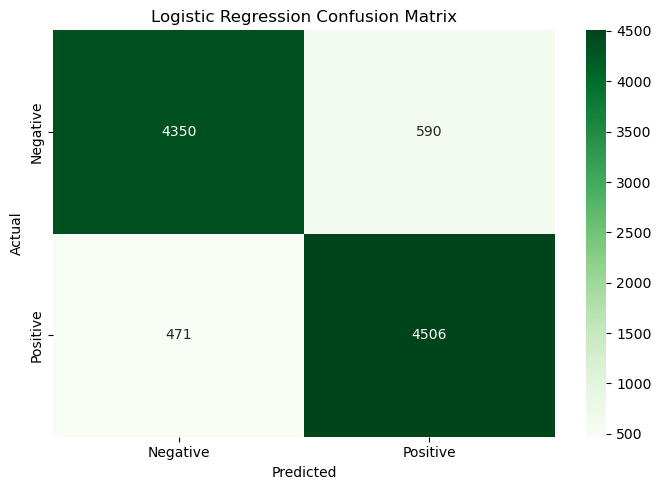

In [49]:
lr_cm = confusion_matrix(
    y_test,
    lr_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    lr_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=[
        "Negative",
        "Positive"
    ],
    yticklabels=[
        "Negative",
        "Positive"
    ]
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [50]:
results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression"
    ],
    
    "Accuracy": [
        nb_accuracy,
        lr_accuracy
    ],
    
    "Precision": [
        nb_precision,
        lr_precision
    ],
    
    "Recall": [
        nb_recall,
        lr_recall
    ],
    
    "F1 Score": [
        nb_f1,
        lr_f1
    ]
})

results = results.round(4)

display(results)

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.8649,0.8561,0.8784,0.8671
1,Logistic Regression,0.8930,0.8842,0.9054,0.8947


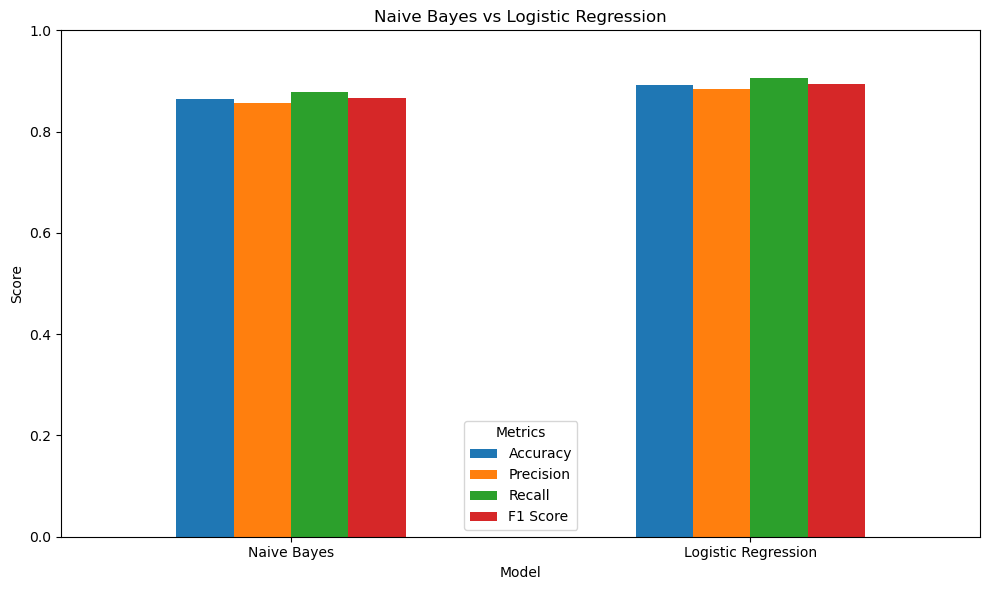

In [51]:
results_plot = results.set_index(
    "Model"
)

results_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Naive Bayes vs Logistic Regression"
)

plt.xlabel("Model")
plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.legend(
    title="Metrics"
)

plt.tight_layout()
plt.show()

In [52]:
best_model_row = results.loc[
    results["F1 Score"].idxmax()
]

best_model_name = best_model_row["Model"]

print(
    "Best Model:",
    best_model_name
)

print(
    "Best F1 Score:",
    best_model_row["F1 Score"]
)

Best Model: Logistic Regression
Best F1 Score: 0.8947


In [53]:
positive_text = " ".join(
    clean_df.loc[
        clean_df["sentiment_label"] == 1,
        "cleaned_review"
    ]
)

print(
    "Positive review text prepared."
)

Positive review text prepared.


In [54]:
positive_wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=200
).generate(
    positive_text
)

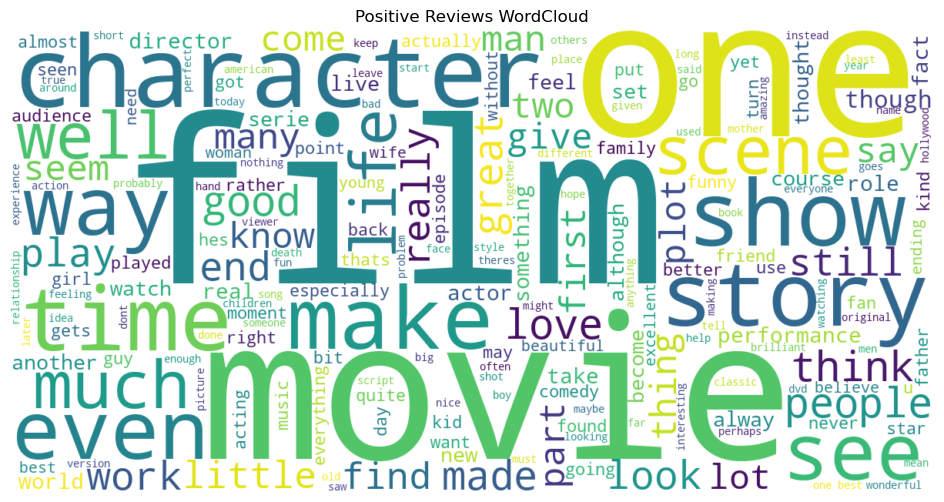

In [55]:
plt.figure(figsize=(12, 6))

plt.imshow(
    positive_wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title(
    "Positive Reviews WordCloud"
)

plt.show()

In [56]:
negative_text = " ".join(
    clean_df.loc[
        clean_df["sentiment_label"] == 0,
        "cleaned_review"
    ]
)

print(
    "Negative review text prepared."
)

Negative review text prepared.


In [57]:
negative_wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=200
).generate(
    negative_text
)


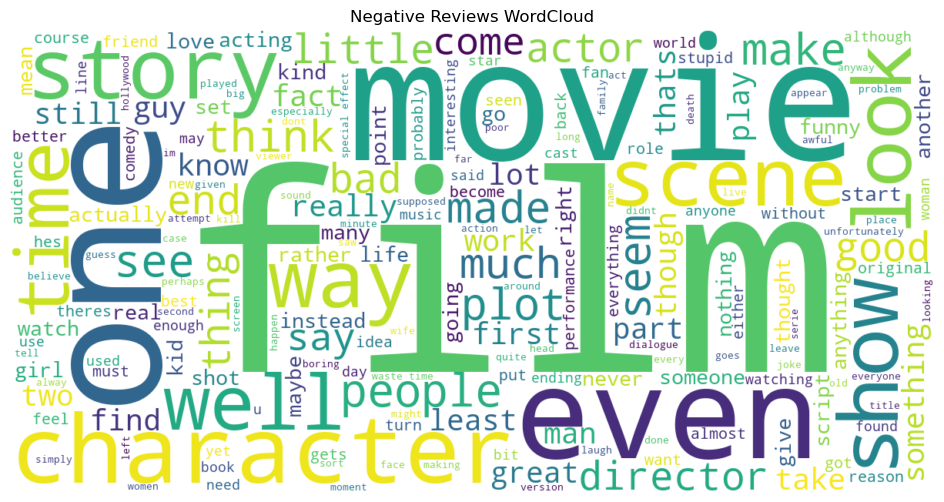

In [58]:
plt.figure(figsize=(12, 6))

plt.imshow(
    negative_wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title(
    "Negative Reviews WordCloud"
)

plt.show()

In [59]:
if best_model_name == "Naive Bayes":
    best_predictions = nb_predictions
else:
    best_predictions = lr_predictions

In [60]:
error_analysis = pd.DataFrame({
    "Review": X_test.values,
    "Actual": y_test.values,
    "Predicted": best_predictions
})

errors = error_analysis[
    error_analysis["Actual"] !=
    error_analysis["Predicted"]
].copy()

print(
    "Total incorrect predictions:",
    len(errors)
)

Total incorrect predictions: 1061


In [61]:
for i, row in errors.head(5).iterrows():

    print("=" * 80)

    print("Review:")
    print(row["Review"])

    print(
        "\nActual:",
        "Positive"
        if row["Actual"] == 1
        else "Negative"
    )

    print(
        "Predicted:",
        "Positive"
        if row["Predicted"] == 1
        else "Negative"
    )

print("=" * 80)

Review:
film started got feeling going something special acting camera work undoubtedly good also liked characters could grown empathise film good atmosphere hint fantasy however film went plot never appeared takeoff rolled scene scene unable understand connection stories could see characters occasionally bumping references ships bottles without connection left unremarkable short stories surprised well cannes

Actual: Negative
Predicted: Positive
Review:
despite huge fan fred astaire ginger rogers movies wasnt years ago first saw follow fleet knew songs old astairerogers record yes vinyl knew nothing plot unfortunately songs catchy ginger rogers character sweet funny cant like bake baker trying make longtime partner continually sabotages career character doesnt usual humour elan films astaire characters worth watching songs great solo tap routine ginger rogers

Actual: Negative
Predicted: Positive
Review:
well wellroeg touched bit nerve didnt genius cataloguing various characters desce

In [63]:
clean_df.to_csv(
    "cleaned_IMDB_reviews.csv",
    index=False
)

print(
    "Cleaned dataset saved successfully!"
)

Cleaned dataset saved successfully!
